# Notebook 01 — Training Base Models

**Linear Mode Connectivity, Model Alignment and Functional Repair**
*Deep Learning & Applied AI — Sapienza Università di Roma, 2025/2026*

---

## Overview

This notebook trains all base model pairs needed for the LMC study.
We use two architecture–dataset pairings deliberately chosen to **not overlap**
with those in the course notebooks (which use MNIST, CIFAR, VGG, ResNet):

| Setup | Architecture | Dataset | Why |
|-------|-------------|---------|-----|
| A | **MLP-3** (3 hidden layers, no BN) | **KMNIST** (28×28, 10 classes) | Clean permutation symmetry — ideal control for alignment |
| B | **SimpleConvBN** (5-layer ConvNet + BN) | **SVHN** (32×32 RGB, 10 classes) | BatchNorm layers — ideal testbed for REPAIR |

**Scenarios:**
- **Scenario 1 — Independent:** Two different random seeds.
- **Scenario 2 — Spawning:** Shared first $k$ epochs, then diverge (H1).


## 1. Setup & Configuration

### Reproducibility (`src/utils.py`)

Our `set_seed(seed)` function pins **all** sources of randomness:

```python
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
```

This is critical for the LMC study: we need to be sure that
differences between model A and model B come **only** from the
seed, not from non-deterministic operations.

### Data Loading (`src/utils.py`)

`get_dataloaders(name, batch_size)` handles dataset-specific
preprocessing:

- **KMNIST:** `ToTensor()` → `Normalize(μ=0.1918, σ=0.3483)`
- **SVHN:** `RandomCrop(32, pad=4)` → `ToTensor()` → `Normalize(μ=(0.438, 0.444, 0.473), σ=(0.198, 0.201, 0.197))`

SVHN uses `split='train'/'test'` instead of `train=True/False`
(different API from MNIST-family datasets in torchvision).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import matplotlib.pyplot as plt
from src.utils import set_seed, get_device, get_dataloaders
from src.models import MLP3, SimpleConvBN, get_model
from src.training import train_model, train_spawned_pair

device = get_device()
print(f"Device: {device}")

os.makedirs("../checkpoints", exist_ok=True)
os.makedirs("../figures", exist_ok=True)


Device: mps


/Users/carlos/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 2. KMNIST — MLP-3 (Control Experiment)

### About KMNIST

**Kuzushiji-MNIST** (Clanuwat et al., 2018) contains 70,000 images of
10 classes of cursive Japanese (*Kuzushiji*) characters at 28×28
grayscale resolution. It is a drop-in replacement for MNIST with the
same format but **significantly harder** (human accuracy ≈ 95%).

### About MLP-3 (`src/models.py`)

A fully-connected network with **three hidden layers** and ReLU activations:

```
Flatten(784) → Linear(784→256) → ReLU
             → Linear(256→256) → ReLU
             → Linear(256→256) → ReLU
             → Linear(256→10)
```

**Total parameters:** 335,114 (≈ 335K).

The architecture is defined with **named layers** (`layer0`, `layer1`,
`layer2`, `layer3`) rather than `nn.Sequential`. This is intentional —
the alignment code (`src/alignment.py`) needs to reference each layer
by name through the `layer_names()` static method:

```python
MLP3.layer_names()  # → ["layer0", "layer1", "layer2", "layer3"]
```

**Why MLP for LMC?** MLPs have the cleanest **permutation symmetry**:
any permutation $P$ of hidden units in layer $\ell$ can be absorbed
by permuting rows/columns of adjacent weight matrices:

$$
f(x;\, W_0, W_1, \ldots) = f(x;\, P^{(\ell)} W^{(\ell)},\;
W^{(\ell+1)} P^{(\ell)\top}, \ldots)
$$

This means two MLPs trained from different seeds may implement
the **same function** with permuted neurons — the key premise of
the LMC hypothesis (Entezari et al., 2022).


KMNIST — train: 60000, test: 10000


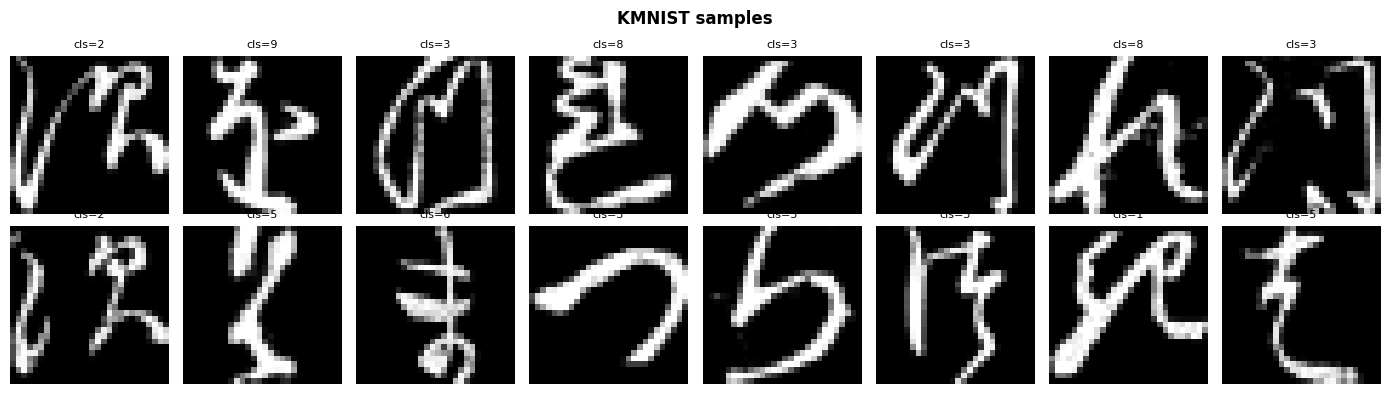

In [2]:
train_loader_k, test_loader_k = get_dataloaders("kmnist", batch_size=128)
print(f"KMNIST — train: {len(train_loader_k.dataset)}, "
      f"test: {len(test_loader_k.dataset)}")

# Visualize a few samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
batch_x, batch_y = next(iter(test_loader_k))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(batch_x[i].squeeze(), cmap="gray")
    ax.set_title(f"cls={batch_y[i].item()}", fontsize=8)
    ax.axis("off")
plt.suptitle("KMNIST samples", fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/kmnist_samples.png", dpi=150)
plt.show()


### Scenario 1 — Independent Training

We train two copies from **different initializations** (seeds 42 and 123).

#### Training loop (`src/training.py`)

`train_model()` implements a standard training loop with:

- **Optimizer:** Adam with weight decay $10^{-4}$
- **Scheduler:** Cosine annealing (`CosineAnnealingLR`) over the
  total number of epochs — smoothly decays the learning rate to near zero.
- **Checkpointing:** Saves `state_dict` + training history to disk.

The `train_one_epoch()` function returns `(avg_loss, accuracy)` using
an `AverageMeter` that tracks running statistics without storing
all batch values in memory.

Key expectation: naively interpolating weights
$\theta(\alpha) = \alpha\theta_A + (1-\alpha)\theta_B$ should
produce **very high loss** at $\alpha \approx 0.5$ because the
minima are separated by a loss barrier.


In [3]:
set_seed(42)
mlp_a = MLP3().to(device)
hist_a = train_model(
    mlp_a, train_loader_k, test_loader_k,
    epochs=30, lr=1e-3,
    save_dir="../checkpoints", tag="mlp3_independent_A",
    device=device,
)

print(f"MLP-3 A final test acc: {hist_a['test_acc'][-1]:.4f}")



Training mlp3_independent_A: 100%|██████████| 30/30 [01:58<00:00,  3.94s/it, lr=0.0e+00, te_acc=0.920, tr_acc=1.000]

  → Saved ../checkpoints/mlp3_independent_A.pt
MLP-3 A final test acc: 0.9205


In [4]:
set_seed(123)
mlp_b = MLP3().to(device)
hist_b = train_model(
    mlp_b, train_loader_k, test_loader_k,
    epochs=30, lr=1e-3,
    save_dir="../checkpoints", tag="mlp3_independent_B",
    device=device,
)
print(f"MLP-3 B final test acc: {hist_b['test_acc'][-1]:.4f}")


Training mlp3_independent_B: 100%|██████████| 30/30 [02:00<00:00,  4.00s/it, lr=0.0e+00, te_acc=0.919, tr_acc=1.000]

  → Saved ../checkpoints/mlp3_independent_B.pt
MLP-3 B final test acc: 0.9193


### Training Curves

Both models should reach similar final accuracy (~93–96% on KMNIST),
confirming they found comparably good solutions despite different seeds.


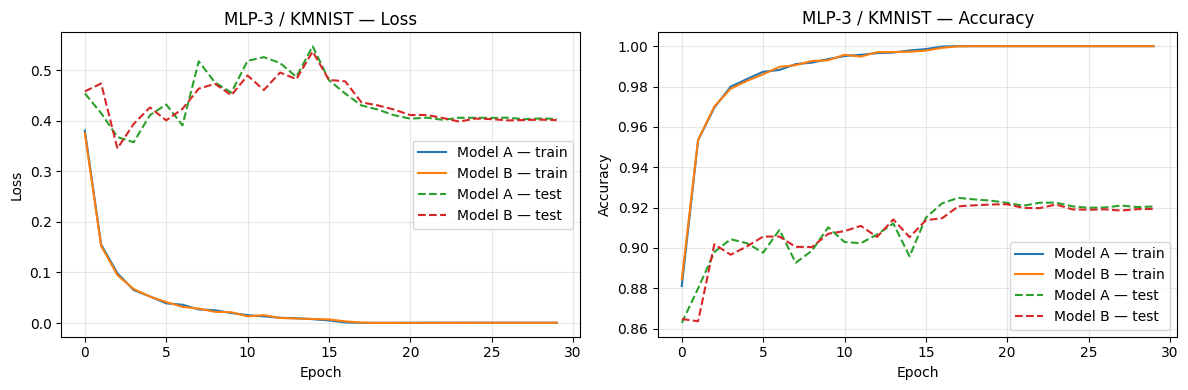

Model A test acc: 0.9205
Model B test acc: 0.9193


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_a["train_loss"], label="Model A — train")
ax1.plot(hist_b["train_loss"], label="Model B — train")
ax1.plot(hist_a["test_loss"], "--", label="Model A — test")
ax1.plot(hist_b["test_loss"], "--", label="Model B — test")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("MLP-3 / KMNIST — Loss"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_a["train_acc"], label="Model A — train")
ax2.plot(hist_b["train_acc"], label="Model B — train")
ax2.plot(hist_a["test_acc"], "--", label="Model A — test")
ax2.plot(hist_b["test_acc"], "--", label="Model B — test")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("MLP-3 / KMNIST — Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/mlp3_kmnist_training.png", dpi=150)
plt.show()

print(f"Model A test acc: {hist_a['test_acc'][-1]:.4f}")
print(f"Model B test acc: {hist_b['test_acc'][-1]:.4f}")


### Scenario 2 — Spawning (Frankle et al., 2020)

#### The spawning protocol (`src/training.py → train_spawned_pair`)

1. **Phase 1 (shared):** Initialize a model with `seed_common`,
   train for $k$ epochs. This is the shared trunk.

   
2. **Phase 2 (diverge):** `deepcopy` the model into A and B, then
   train each independently with `seed_a` and `seed_b` for the
   remaining epochs.

```
Epoch:   0 ──── k ──────────── 30
         │  shared  │
         │          ├── seed_a → θ_A
         │          └── seed_b → θ_B
```

The function returns `(model_a, model_b, history_a, history_b)`.

We sweep $k \in \{0, 1, 2, 5, 10, 20\}$:
- $k = 0$: A and B start in the same initialization(seed_common) and only diverge in the order of the data, **Is not equivalent to the independet scenarion**, where initializations are different.
- $k = 20$: 2/3 of training is shared — expect near-zero barrier.

**H1 asks:** how small can $k$ be while still achieving LMC?


In [6]:
spawn_epochs = [0, 1, 2, 5, 10, 20]
spawn_results = {}

for k in spawn_epochs:
    print(f"\n{'='*50}")
    print(f"Spawning with k={k} shared epochs")
    print(f"{'='*50}")

    ma, mb, ha, hb = train_spawned_pair(
        model_class=MLP3,
        model_kwargs={"input_dim": 784, "hidden": 256, "num_classes": 10},
        train_loader=train_loader_k,
        test_loader=test_loader_k,
        total_epochs=30,
        spawn_epoch=k,
        device=device,
        save_dir="../checkpoints",
    )
    spawn_results[k] = {
        "model_a": ma, "model_b": mb,
        "hist_a": ha, "hist_b": hb,
    }
    print(f"  k={k}: A={ha['test_acc'][-1]:.4f}, B={hb['test_acc'][-1]:.4f}")



Spawning with k=0 shared epochs
Phase 1: shared training for 0 epochs (seed=0)
Phase 2: independent training for 30 epochs


Training spawned_k0_A: 100%|██████████| 30/30 [02:01<00:00,  4.05s/it, lr=0.0e+00, te_acc=0.918, tr_acc=1.000]


  → Saved ../checkpoints/spawned_k0_A.pt


Training spawned_k0_B: 100%|██████████| 30/30 [01:55<00:00,  3.86s/it, lr=0.0e+00, te_acc=0.918, tr_acc=1.000]


  → Saved ../checkpoints/spawned_k0_B.pt
  k=0: A=0.9180, B=0.9184

Spawning with k=1 shared epochs
Phase 1: shared training for 1 epochs (seed=0)
Phase 2: independent training for 29 epochs


...

  → Saved ../checkpoints/spawned_k10_B.pt
  k=10: A=0.9234, B=0.9223

Spawning with k=20 shared epochs
Phase 1: shared training for 20 epochs (seed=0)
Phase 2: independent training for 10 epochs


Training spawned_k20_A: 100%|██████████| 10/10 [00:38<00:00,  3.83s/it, lr=0.0e+00, te_acc=0.924, tr_acc=1.000]


  → Saved ../checkpoints/spawned_k20_A.pt


Training spawned_k20_B: 100%|██████████| 10/10 [00:38<00:00,  3.83s/it, lr=0.0e+00, te_acc=0.926, tr_acc=1.000]

  → Saved ../checkpoints/spawned_k20_B.pt
  k=20: A=0.9239, B=0.9259


In [7]:
for k, res in spawn_results.items():
    torch.save(res["model_a"].state_dict(),
               f"../checkpoints/mlp3_kmnist_spawn_k{k}_A.pt")
    torch.save(res["model_b"].state_dict(),
               f"../checkpoints/mlp3_kmnist_spawn_k{k}_B.pt")


---
## 3. SVHN — SimpleConvBN

### About SVHN

**Street View House Numbers** (Netzer et al., 2011): 32×32 RGB images
of digits from Google Street View. 73,257 training + 26,032 test images.
Real-world photographs with clutter and varying lighting.

### About SimpleConvBN (`src/models.py`)

A custom 5-layer ConvNet with **BatchNorm at every stage**:

| Layer | Operation | Output | Params |
|-------|-----------|--------|--------|
| 0 | `Conv2d(3→32, 3×3, pad=1)` → `BN2d(32)` → `ReLU` → `MaxPool(2)` | 32×16×16 | 896 + 64 |
| 1 | `Conv2d(32→64, 3×3, pad=1)` → `BN2d(64)` → `ReLU` → `MaxPool(2)` | 64×8×8 | 18,496 + 128 |
| 2 | `Conv2d(64→128, 3×3, pad=1)` → `BN2d(128)` → `ReLU` → `MaxPool(2)` | 128×4×4 | 73,856 + 256 |
| 3 | `Linear(2048→256)` → `BN1d(256)` → `ReLU` | 256 | 524,544 + 512 |
| 4 | `Linear(256→10)` | 10 | 2,570 |

**Total: 621,322 parameters.**

#### Why BatchNorm matters for LMC

Each `BatchNorm` layer stores **running statistics** that are
accumulated during training via exponential moving average:

$$
\mu_\text{run} \leftarrow (1-m)\,\mu_\text{run} + m\,\mu_\text{batch}
$$

These statistics are **specific to each model's weight configuration**.
When we interpolate weights, the BN running stats become *stale* —
they no longer match the actual activation distributions, causing
large performance drops.

The `bn_names()` static method returns `["bn0", "bn1", "bn2", "bn_fc"]`
so that the REPAIR code can find and recalibrate them.

#### Permutation structure of ConvNets

Conv layers have 4D weights $(C_\text{out}, C_\text{in}, k_H, k_W)$.
Permuting **output channels** (axis 0) of conv layer $\ell$ requires:
1. Permuting rows of `conv_l.weight` and `conv_l.bias`
2. Permuting all BN params (`bn_l.weight`, `bn_l.bias`, `running_mean`, `running_var`)
3. Permuting **input channels** (axis 1) of `conv_{l+1}.weight`

At the **Conv→FC boundary** (`conv2` → `fc0`), the flattening from
$(128, 4, 4)$ to $2048$ means a channel permutation becomes a
**block permutation** of 16-element blocks ($4 \times 4 = 16$).


SVHN — train: 73257, test: 26032


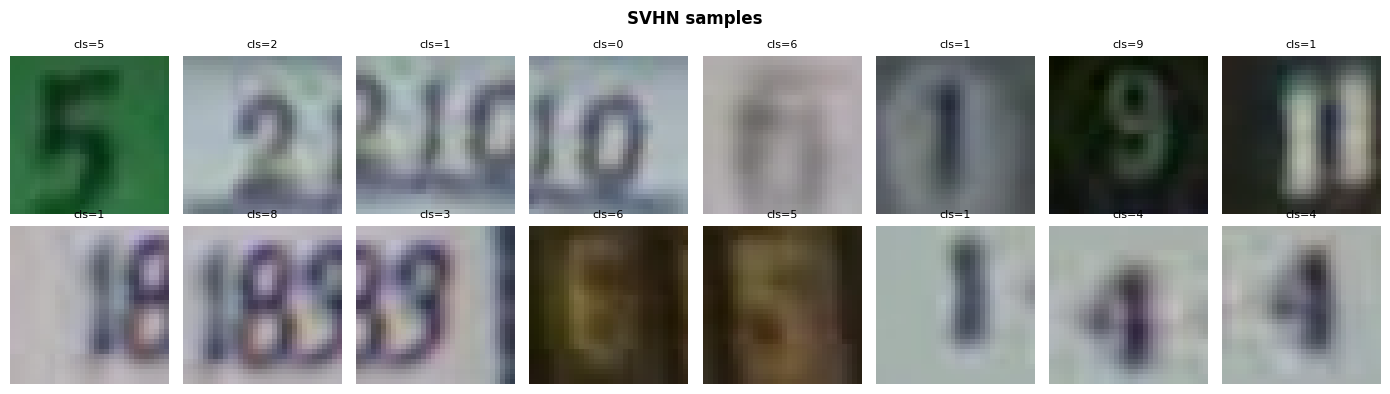

In [8]:
train_loader_s, test_loader_s = get_dataloaders("svhn", batch_size=128)
print(f"SVHN — train: {len(train_loader_s.dataset)}, "
      f"test: {len(test_loader_s.dataset)}")

# Visualize
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
batch_x, batch_y = next(iter(test_loader_s))
for i, ax in enumerate(axes.ravel()):
    img = batch_x[i].permute(1, 2, 0).numpy()
    img = img * 0.198 + 0.443  # approximate denormalization
    ax.imshow(img.clip(0, 1))
    ax.set_title(f"cls={batch_y[i].item()}", fontsize=8)
    ax.axis("off")
plt.suptitle("SVHN samples", fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/svhn_samples.png", dpi=150)
plt.show()


### Scenario 1 — Independent Training (SimpleConvBN)


In [9]:
set_seed(42)
conv_a = SimpleConvBN().to(device)
hist_ca = train_model(
    conv_a, train_loader_s, test_loader_s,
    epochs=30, lr=1e-3,
    save_dir="../checkpoints", tag="convbn_svhn_A",
    device=device,
)


Training convbn_svhn_A: 100%|██████████| 30/30 [08:03<00:00, 16.11s/it, lr=0.0e+00, te_acc=0.947, tr_acc=0.974]

  → Saved ../checkpoints/convbn_svhn_A.pt


In [10]:
set_seed(123)
conv_b = SimpleConvBN().to(device)
hist_cb = train_model(
    conv_b, train_loader_s, test_loader_s,
    epochs=30, lr=1e-3,
    save_dir="../checkpoints", tag="convbn_svhn_B",
    device=device,
)


Training convbn_svhn_B:   0%|          | 0/30 [00:00<?, ?it/s]

Training convbn_svhn_B: 100%|██████████| 30/30 [08:24<00:00, 16.81s/it, lr=0.0e+00, te_acc=0.947, tr_acc=0.974]

  → Saved ../checkpoints/convbn_svhn_B.pt


### Training Curves


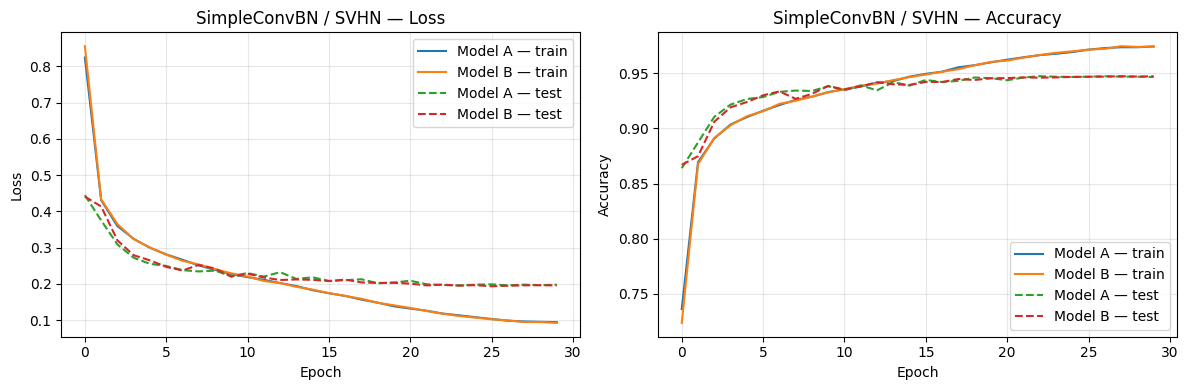

Model A test acc: 0.9466
Model B test acc: 0.9473


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_ca["train_loss"], label="Model A — train")
ax1.plot(hist_cb["train_loss"], label="Model B — train")
ax1.plot(hist_ca["test_loss"], "--", label="Model A — test")
ax1.plot(hist_cb["test_loss"], "--", label="Model B — test")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("SimpleConvBN / SVHN — Loss"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_ca["train_acc"], label="Model A — train")
ax2.plot(hist_cb["train_acc"], label="Model B — train")
ax2.plot(hist_ca["test_acc"], "--", label="Model A — test")
ax2.plot(hist_cb["test_acc"], "--", label="Model B — test")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("SimpleConvBN / SVHN — Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/convbn_svhn_training.png", dpi=150)
plt.show()

print(f"Model A test acc: {hist_ca['test_acc'][-1]:.4f}")
print(f"Model B test acc: {hist_cb['test_acc'][-1]:.4f}")


### Scenario 2 — Spawning (SimpleConvBN)

With BatchNorm, the spawning effect may differ from MLP-3:
even after diverging, the BN running statistics are accumulated
independently, creating an additional source of mismatch beyond
weight permutations.


In [12]:
spawn_results_conv = {}

for k in [0, 1, 2, 5, 10, 20]:
    print(f"\nSpawning k={k}...")
    ma, mb, ha, hb = train_spawned_pair(
        model_class=SimpleConvBN,
        model_kwargs={"num_classes": 10},
        train_loader=train_loader_s,
        test_loader=test_loader_s,
        total_epochs=30,
        spawn_epoch=k,
        device=device,
        save_dir="../checkpoints",
    )
    spawn_results_conv[k] = {"model_a": ma, "model_b": mb}
    torch.save(ma.state_dict(),
               f"../checkpoints/convbn_svhn_spawn_k{k}_A.pt")
    torch.save(mb.state_dict(),
               f"../checkpoints/convbn_svhn_spawn_k{k}_B.pt")
    print(f"  k={k}: A={ha['test_acc'][-1]:.4f}, B={hb['test_acc'][-1]:.4f}")



Spawning k=0...
Phase 1: shared training for 0 epochs (seed=0)
Phase 2: independent training for 30 epochs


Training spawned_k0_A: 100%|██████████| 30/30 [09:58<00:00, 19.96s/it, lr=0.0e+00, te_acc=0.947, tr_acc=0.975]


  → Saved ../checkpoints/spawned_k0_A.pt


Training spawned_k0_B: 100%|██████████| 30/30 [09:58<00:00, 19.97s/it, lr=0.0e+00, te_acc=0.949, tr_acc=0.975]


  → Saved ../checkpoints/spawned_k0_B.pt
  k=0: A=0.9466, B=0.9489

Spawning k=1...
Phase 1: shared training for 1 epochs (seed=0)
Phase 2: independent training for 29 epochs


...

  → Saved ../checkpoints/spawned_k10_B.pt
  k=10: A=0.9499, B=0.9499

Spawning k=20...
Phase 1: shared training for 20 epochs (seed=0)
Phase 2: independent training for 10 epochs


Training spawned_k20_A: 100%|██████████| 10/10 [02:48<00:00, 16.86s/it, lr=0.0e+00, te_acc=0.951, tr_acc=0.974]


  → Saved ../checkpoints/spawned_k20_A.pt


Training spawned_k20_B: 100%|██████████| 10/10 [02:47<00:00, 16.78s/it, lr=0.0e+00, te_acc=0.952, tr_acc=0.973]

  → Saved ../checkpoints/spawned_k20_B.pt
  k=20: A=0.9514, B=0.9518


---
## 4. Summary

All base models trained and saved to `../checkpoints/`.

| File pattern | Architecture | Dataset |
|---|---|---|
| `mlp3_independent_{A,B}.pt` | MLP-3 | KMNIST |
| `mlp3_kmnist_spawn_k{K}_{A,B}.pt` | MLP-3 (spawned) | KMNIST |
| `convbn_svhn_{A,B}.pt` | SimpleConvBN | SVHN |
| `convbn_svhn_spawn_k{K}_{A,B}.pt` | SimpleConvBN (spawned) | SVHN |

**Next → Notebook 02**: Alignment methods and barrier measurement.
